<a href="https://colab.research.google.com/github/harshs-data/Pytorch/blob/main/CNN_using_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)

100%|██████████| 68.8M/68.8M [00:00<00:00, 149MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/zalando-research/fashionmnist/versions/4


In [3]:
import pandas as pd

# Assuming there is a file named 'fashion-mnist_train.csv' in that folder
# Adjust the filename based on what you saw in Step 2
df = pd.read_csv(f"{path}/fashion-mnist_train.csv")

# Look at the first 5 rows
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


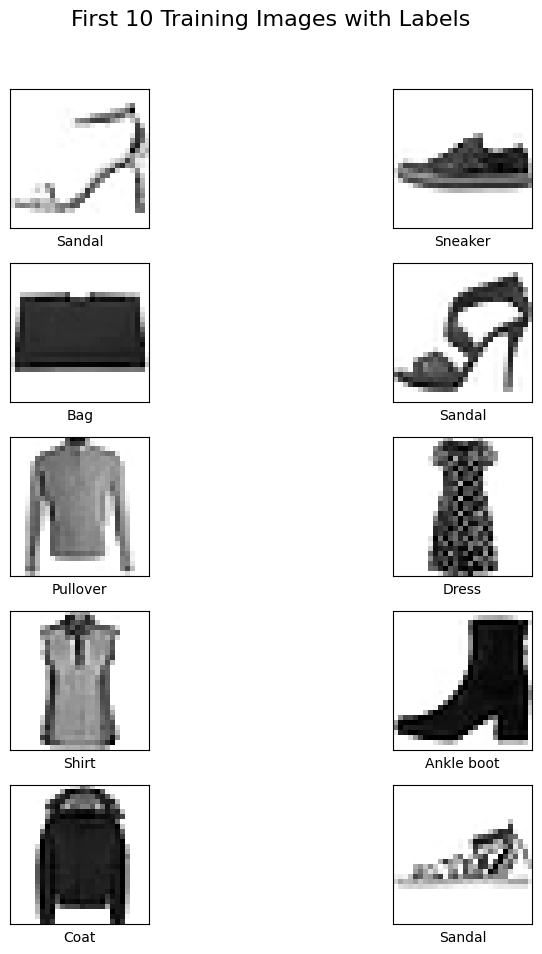

In [24]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10, 10))
for i in range(10):
    image, label = train_dataset[i]
    plt.subplot(5, 2, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(image.squeeze(), cmap=plt.cm.binary)
    plt.xlabel(class_names[label])
plt.suptitle('First 10 Training Images with Labels', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [4]:
# check for GPU

import torch

# This automatically picks GPU if available, otherwise stays on CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {device}")

Using device: cuda


In [5]:
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [6]:
# train test split
X_train, X_test, y_train, y_test =train_test_split(X,y, test_size=0.20, random_state=42)

In [7]:
X_train = X_train/255.0
X_test = X_test/255.0

In [9]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    self.features = torch.tensor(features, dtype = torch.float32).reshape(-1,1,28,28)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, idx):
    return self.features[idx], self.labels[idx]



In [10]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [11]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [12]:
class MyNN(nn.Module):

  def __init__(self, input_features):

    super().__init__()

    # feature extraction (convolution layer + pooling layer)
    self.features = nn.Sequential(
        nn.Conv2d(input_features, 32, kernel_size=3, padding= 'same'),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(32, 64, kernel_size=3, padding= 'same'),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    # fully connected layer
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64*7*7, 128),
        nn.ReLU(),
        nn.Dropout(p = 0.4),

        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(p = 0.4),

        nn.Linear(64, 10)
    )

  def forward(self, X):
    X = self.features(X)
    X = self.classifier(X)

    return X

In [13]:
learning_rate=0.01
epochs=100

In [15]:
model = MyNN(1)

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [18]:
# training loop
for epoch in range(epochs):
    model.train() # Set model to training mode
    for batch_features, batch_labels in train_loader:

        # Move data to GPU
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        # forward pass
        outputs = model(batch_features)

        # loss
        loss = criterion(outputs, batch_labels)

        # back pass
        optimizer.zero_grad()
        loss.backward()

        # update weights
        optimizer.step()


KeyboardInterrupt



In [19]:
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train() # Set model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for batch_features, batch_labels in train_loader:

        # Move data to GPU
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        # forward pass
        outputs = model(batch_features)

        # loss
        loss = criterion(outputs, batch_labels)

        # back pass
        optimizer.zero_grad()
        loss.backward()

        # update weights
        optimizer.step()

        running_loss += loss.item() * batch_labels.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_predictions += batch_labels.size(0)
        correct_predictions += (predicted == batch_labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_accuracy = correct_predictions / total_predictions

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}')

Epoch [1/100], Loss: 0.0986, Accuracy: 0.9650
Epoch [2/100], Loss: 0.0962, Accuracy: 0.9662
Epoch [3/100], Loss: 0.0900, Accuracy: 0.9682
Epoch [4/100], Loss: 0.0849, Accuracy: 0.9686
Epoch [5/100], Loss: 0.0816, Accuracy: 0.9705
Epoch [6/100], Loss: 0.0789, Accuracy: 0.9722
Epoch [7/100], Loss: 0.0777, Accuracy: 0.9713
Epoch [8/100], Loss: 0.0706, Accuracy: 0.9750
Epoch [9/100], Loss: 0.0683, Accuracy: 0.9746
Epoch [10/100], Loss: 0.0666, Accuracy: 0.9757
Epoch [11/100], Loss: 0.0638, Accuracy: 0.9766
Epoch [12/100], Loss: 0.0603, Accuracy: 0.9790
Epoch [13/100], Loss: 0.0598, Accuracy: 0.9779
Epoch [14/100], Loss: 0.0560, Accuracy: 0.9802
Epoch [15/100], Loss: 0.0553, Accuracy: 0.9798
Epoch [16/100], Loss: 0.0529, Accuracy: 0.9814
Epoch [17/100], Loss: 0.0510, Accuracy: 0.9819
Epoch [18/100], Loss: 0.0486, Accuracy: 0.9824
Epoch [19/100], Loss: 0.0477, Accuracy: 0.9834
Epoch [20/100], Loss: 0.0475, Accuracy: 0.9841
Epoch [21/100], Loss: 0.0432, Accuracy: 0.9850
Epoch [22/100], Loss: 

In [20]:
# Evaluation
model.eval()

total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move to GPU
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    outputs = model(batch_features)

    _,predicted = torch.max(outputs,1)

    total = total + batch_labels.size(0)

    correct = correct + (predicted == batch_labels).sum().item()

  accuracy = correct/total

print(f'Test Accuracy: {accuracy:.4f}')

Test Accuracy: 0.9244


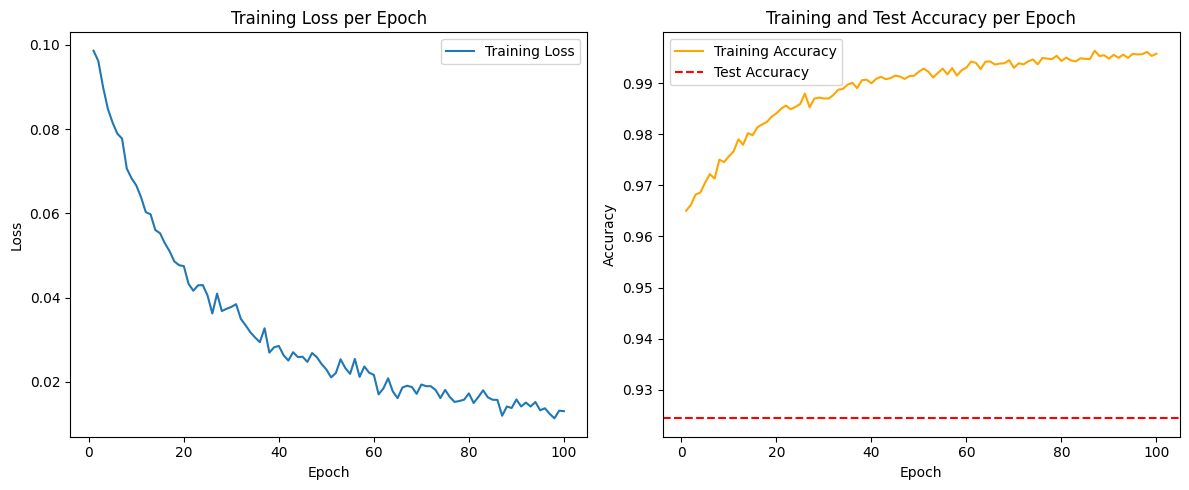

In [22]:
# Plotting training loss and accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_accuracies, label='Training Accuracy', color='orange')
plt.axhline(y=accuracy, color='red', linestyle='--', label='Test Accuracy') # Add test accuracy
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy per Epoch')
plt.legend()

plt.tight_layout()
plt.show()